<a href="https://colab.research.google.com/github/suuu004/RL/blob/main/Q_learning_vs_QDN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Set the Runtime -> CPU standard

Training Tabular Q-Learning...
Training Deep Q-Network (DQN)...


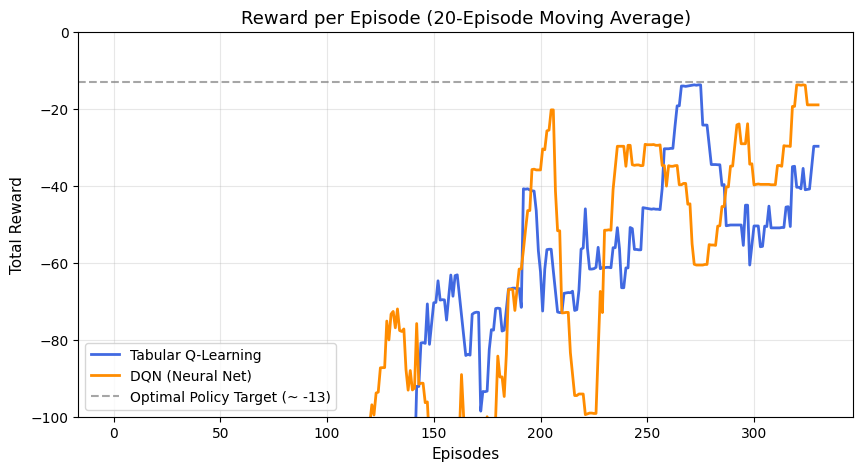

In [17]:
import collections
import random
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

## tabular Q-learning agent
class TabularQLearningAgent:
  def __init__(self, num_states=48, num_actions=4, lr=0.1, gamma = 0.99):
      self.num_actions= num_actions
      self.lr = lr
      self.gamma = gamma
      self.q_table = np.zeros((num_states, num_actions))
  def act(self, state, epsilon):
    if random.random()< epsilon:
      return random.randint(0, self.num_actions - 1)
    return int(np.argmax(self.q_table[state]))

  def update(self, s, a, r , next_s, done):
    best_next_q = 0.0 if done else np.max(self.q_table[next_s])
    target = r + self.gamma * best_next_q
    self.q_table[s, a] += self.lr*(target - self.q_table[s,a])


## Deep Q-Network agent
class QNetwork(nn.Module):
  def __init__(self, input_dim=48, output_dim = 4):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, output_dim)
    )
  def forward(self, x):
    return self.net(x)

class DQNAgent:
  def __init__(self, num_states=48, num_actions=4, lr=0.001, gamma=0.99, batch_size=32):
    self.num_states = num_states
    self.num_actions = num_actions
    self.gamma = gamma
    self.batch_size = batch_size

    self.policy_net = QNetwork(num_states, num_actions)
    self.target_net = QNetwork(num_states, num_actions)
    self.target_net.load_state_dict(self.policy_net.state_dict())
    self.target_net.eval()

    self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
    self.criterion = nn.MSELoss()
    self.replay_buffer = collections.deque(maxlen=5000)

  def _to_one_hot(self, state):
    vec = np.zeros(self.num_states, dtype=np.float32)
    vec[state] = 1.0
    return vec

  def act(self, state, epsilon):
    if random.random() < epsilon:
      return random.randint(0, self.num_actions -1)
    with torch.no_grad():
      s_t = torch.tensor(self._to_one_hot(state)).unsqueeze(0)
      return int(self.policy_net(s_t).argmax(dim=1).item())

  def store_transition(self, s, a, r, next_s, done):
    self.replay_buffer.append((self._to_one_hot(s), a, r, self._to_one_hot(next_s), done))

  def update(self):
    if len(self.replay_buffer) < self.batch_size:
      return

    batch = random.sample(self.replay_buffer, self.batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    b_states = torch.tensor(np.array(states), dtype=torch.float32)
    b_actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
    b_rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
    b_next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
    b_dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

    q_pred = self.policy_net(b_states).gather(1, b_actions)

    with torch.no_grad():
      next_q = self.target_net(b_next_states).max(dim=1, keepdim=True)[0]
      target = b_rewards + (1.0 - b_dones) * self.gamma * next_q

    loss = self.criterion(q_pred, target)
    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

  def sync_target_network(self):
    self.target_net.load_state_dict(self.policy_net.state_dict())


## Experiment execution & Visualization
def run_experiment(agent_type="tabular", episodes=350):
    env = gym.make("CliffWalking-v1")
    agent = TabularQLearningAgent(48, 4) if agent_type == "tabular" else DQNAgent(48, 4)

    rewards_history = []
    epsilon = 1.0
    eps_decay = 0.99
    eps_min = 0.05

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.act(state, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if agent_type == "tabular":
                agent.update(state, action, reward, next_state, done)
            else:
                agent.store_transition(state, action, reward, next_state, done)
                agent.update()

            state = next_state
            total_reward += reward

        if agent_type == "dqn" and ep % 10 == 0:
            agent.sync_target_network()

        epsilon = max(eps_min, epsilon * eps_decay)
        rewards_history.append(total_reward)

    env.close()
    return rewards_history

# Run both experiments
print("Training Tabular Q-Learning...")
tabular_rewards = run_experiment("tabular", episodes=350)

print("Training Deep Q-Network (DQN)...")
dqn_rewards = run_experiment("dqn", episodes=350)

# Moving average helper for smoother curves
def moving_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

# Plotting the results directly inside Colab
plt.figure(figsize=(10, 5))
plt.plot(moving_average(tabular_rewards), label="Tabular Q-Learning", color="royalblue", lw=2)
plt.plot(moving_average(dqn_rewards), label="DQN (Neural Net)", color="darkorange", lw=2)
plt.axhline(y=-13, color="gray", linestyle="--", alpha=0.7, label="Optimal Policy Target (~ -13)")
plt.title("Reward per Episode (20-Episode Moving Average)", fontsize=13)
plt.xlabel("Episodes", fontsize=11)
plt.ylabel("Total Reward", fontsize=11)
plt.ylim(-100, 0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 결과
위 그래프는 tabular Q-learning과 Deep Q-Network 사이에서 학습 동역학 및 안전성 차이를 보여준다. 초반 120 에피소드 부근까지는 탐색률이 높아 에이전트가 자주 낭떠러지로 떨어지며 -100점 패널티를 받아 두 모델 모두 보상이 -100점 이하에 머무른다. 이후 탐색률이 점차 감소하는 130 에피소드 이후부터 목적지에 도달하는 경로를 학습하기 시작하며, 두 모델 모두 이론상 최적 보상 수준인 약 -13점 부근에 도달한다.

하지만 학습 안정성과 업데이트 방식에서 차이가 뚜렷하게 나타난다.
- 테이블 기반 Q-learning(blue): 260 -275 에피소드 부근에서 최적 수준에 도달한 뒤 비교적 안정적인 흐름을 유지한다. 간혹 보상이 떨어지는 구간은 잔여 탐색으로 인한 일시적 실수일 뿐이며, 특정 좌표의 테이블 값을 갱신하더라도 다른 좌표에 영향을 주지 않아 기존에 학습한 정책이 파괴되지 않는다.
- DQN(orange): 205 에피소드 무렵 빠르게 최적 성능 근처에 도달하지만, 바로 220 부근에서 다시 -100점으로 급학하는 등 변동 폭이 매우 크다. 이는 인공신경망 함수 근사의 특성 때문이다. 리플레이 버퍼에서 추출한 미니배치로 역전파를 수행할 때 공유 가중치가 전체 상태 공간에 동시에 영향을 미치므로, 낭떠러지 경계면과 같은 특정 상태의 Q-값이 왜곡되어 한순간에 성능 붕괴가 일어났다가 추가 학습을 통해 이를 다시 복구하는 과정을 반복하게 된다.